Question 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
index = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']

prices_df = pd.DataFrame(data, index=index)

returns_df = prices_df.pct_change()


print("Daily Percentage Returns Matrix")
display(returns_df)

Daily Percentage Returns Matrix


,RELIANCE,INFY,HDFCBANK,TATAMOTORS
Day 1,NaN,NaN,NaN,NaN
Day 2,0.017857,0.013793,-0.012500,0.028846
Day 3,-0.007018,-0.006803,0.018987,-0.013084
Day 4,0.024735,0.020548,0.009317,0.022727
Day 5,-0.006897,0.013423,-0.006154,0.027778
Day 6,0.024306,-0.006623,0.015480,-0.012613


Units Purchased
RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day 1, dtype: float64

 Daily Portfolio Value
Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


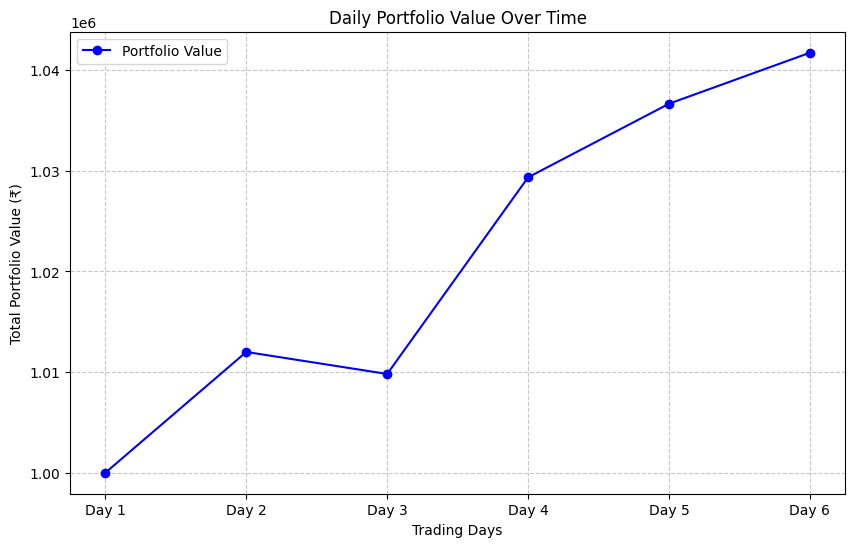

In [2]:
initial_investment = 1000000
weight = 0.25

capital_per_asset = initial_investment * weight

# Compute units purchased based on Day 1
units = capital_per_asset / prices_df.iloc[0]

print("Units Purchased")
print(units)

# Compute daily portfolio value using the vectorized dot product approach
daily_portfolio_values = prices_df.dot(units)

print("\n Daily Portfolio Value")
print(daily_portfolio_values)

plt.figure(figsize=(10, 6))
daily_portfolio_values.plot(marker='o', linestyle='-', color='b')


plt.title('Daily Portfolio Value Over Time')
plt.xlabel('Trading Days')
plt.ylabel('Total Portfolio Value (₹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Portfolio Value'])
plt.show()

In [3]:
# Compute the daily returns of the total portfolio
portfolio_daily_returns = daily_portfolio_values.pct_change()


sigma_daily = portfolio_daily_returns.std()

sigma_annual = sigma_daily * np.sqrt(252)

print(f"Daily Portfolio Volatility:  {sigma_daily:.6f}")
print(f"Annualised Portfolio Volatility: {sigma_annual:.4f} (or {sigma_annual*100:.2f}%)")

Daily Portfolio Volatility:  0.008034
Annualised Portfolio Volatility: 0.1275 (or 12.75%)


Question 2

95% VaR: 0.0214 (Expect losses > 2.14% only 5% of the time)
99% VaR: 0.0286 (Expect losses > 2.86% only 1% of the time)

95% CVaR: 0.0268 (Average loss when 95% VaR is breached)
99% CVaR: 0.0322 (Average loss when 99% VaR is breached)

Maximum Drawdown: 0.1883 (18.83%)


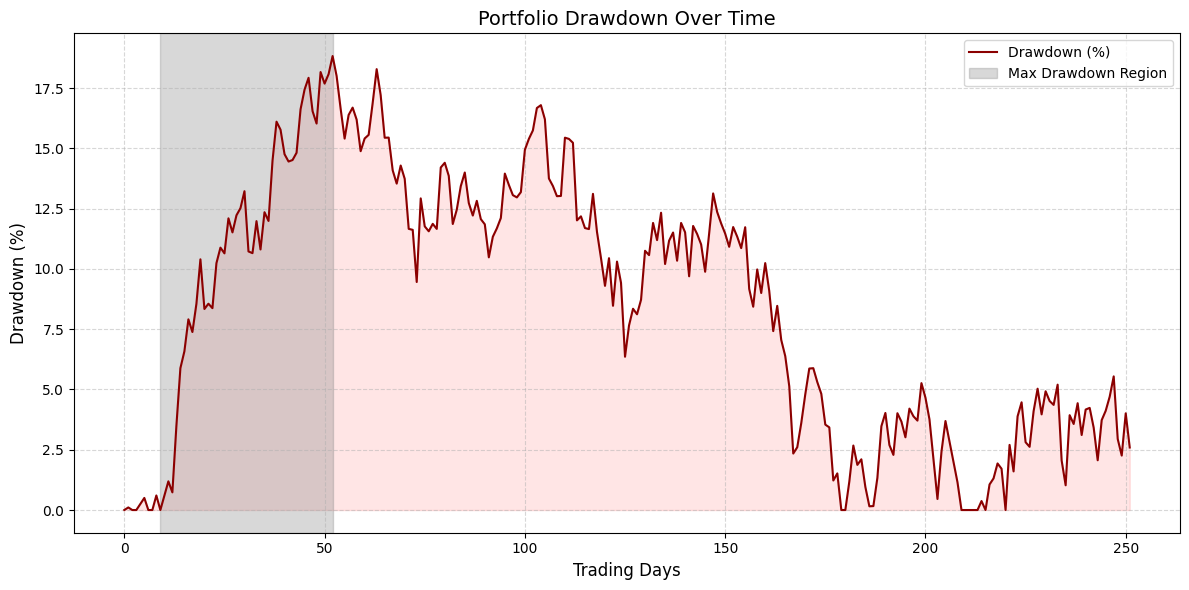

In [7]:
np.random.seed(42)
days = 252
mu = 0.001
sigma = 0.015


R = np.random.normal(loc=mu, scale=sigma, size=days)

# Part A : VAR
var_95 = -np.percentile(R, 100 - 95)
var_99 = -np.percentile(R, 100 - 99)

print(f"95% VaR: {var_95:.4f} (Expect losses > {var_95*100:.2f}% only 5% of the time)")
print(f"99% VaR: {var_99:.4f} (Expect losses > {var_99*100:.2f}% only 1% of the time)")

# Part B: Conditional VaR (CVaR)

cvar_95 = -np.mean(R[R < -var_95])
cvar_99 = -np.mean(R[R < -var_99])

print(f"\n95% CVaR: {cvar_95:.4f} (Average loss when 95% VaR is breached)")
print(f"99% CVaR: {cvar_99:.4f} (Average loss when 99% VaR is breached)")

# Part C: Maximum Drawdown (MaxDD) & Plotting

initial_capital = 1000000
portfolio_values = initial_capital * (1 + R).cumprod()

running_max = np.maximum.accumulate(portfolio_values)


drawdown = (running_max - portfolio_values) / running_max
max_dd = drawdown.max()
trough_idx = drawdown.argmax()
peak_idx = portfolio_values[:trough_idx].argmax() if trough_idx > 0 else 0

print(f"\nMaximum Drawdown: {max_dd:.4f} ({max_dd*100:.2f}%)")

# --- Plotting the Drawdown Curve ---
plt.figure(figsize=(12, 6))

plt.plot(drawdown * 100, color='darkred', linewidth=1.5, label='Drawdown (%)')
plt.fill_between(range(days), drawdown * 100, color='red', alpha=0.1)

plt.axvspan(peak_idx, trough_idx, color='gray', alpha=0.3, label='Max Drawdown Region')

plt.title('Portfolio Drawdown Over Time', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

risk_free_rate_annual = 0.06

# Part A: Compute Sharpe Ratio
annualised_return = R.mean() * 252

annualised_volatility = R.std() * np.sqrt(252)

sharpe_ratio = (annualised_return - risk_free_rate_annual) / annualised_volatility

print(f"Annualised Return: {annualised_return*100:.2f}%")
print(f"Annualised Volatility: {annualised_volatility*100:.2f}%\n")

# Part B: Compute Sortino Ratio

negative_returns = R[R < 0]
annualised_downside_volatility = negative_returns.std() * np.sqrt(252)
sortino_ratio = (annualised_return - risk_free_rate_annual) / annualised_downside_volatility


comparison_df = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe_ratio, sortino_ratio]
})

comparison_df.set_index('Metric', inplace=True)

print(" Risk-Adjusted Performance Metrics")
display(comparison_df.round(4))

Annualised Return: 23.78%
Annualised Volatility: 22.99%

 Risk-Adjusted Performance Metrics


,Value
Metric,
Sharpe Ratio,0.7734
Sortino Ratio,1.4154


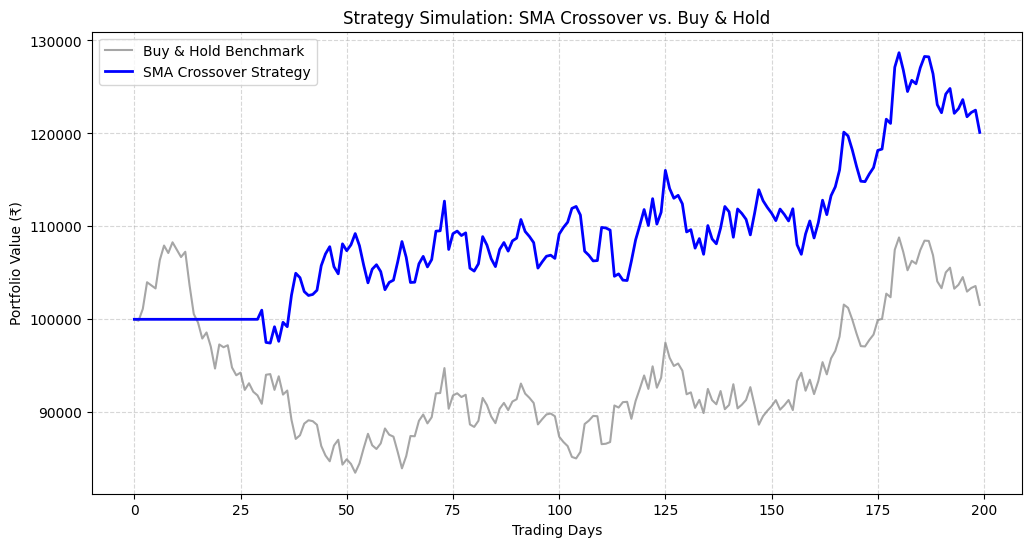

Total Trades Executed: 6
Win Rate:              66.67%
Gross Profit:          ₹21030.55
Gross Loss:            ₹924.99
Profit Factor:         22.7360


/tmp/ipykernel_2119/1525176436.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trade_pnls = active_trades.groupby('Trade_ID').apply(get_trade_pnl)


In [11]:
np.random.seed(42)
days = 200
P0 = 1000

epsilon = np.random.normal(loc=0.001, scale=0.018, size=days)

prices = P0 * np.cumprod(1 + epsilon)

df = pd.DataFrame({'Price': prices})
# Part A: SMA Crossover Strategy & Signal Generation

df['SMA_10'] = df['Price'].rolling(window=10).mean()
df['SMA_30'] = df['Price'].rolling(window=30).mean()


df['Signal'] = 0

df.loc[df['SMA_10'] > df['SMA_30'], 'Signal'] = 1
df.loc[df['SMA_10'] < df['SMA_30'], 'Signal'] = -1

# Part B: Simulate the Strategy

df['Market_Return'] = df['Price'].pct_change()


df['Position'] = df['Signal'].shift(1).fillna(0)
df['Strategy_Return'] = df['Position'] * df['Market_Return']
initial_capital = 100000


df['Cum_Market'] = initial_capital * (1 + df['Market_Return'].fillna(0)).cumprod()
df['Cum_Strategy'] = initial_capital * (1 + df['Strategy_Return'].fillna(0)).cumprod()


plt.figure(figsize=(12, 6))
plt.plot(df['Cum_Market'], label='Buy & Hold Benchmark', color='gray', alpha=0.7)
plt.plot(df['Cum_Strategy'], label='SMA Crossover Strategy', color='blue', linewidth=2)

plt.title('Strategy Simulation: SMA Crossover vs. Buy & Hold')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Part C: Win Rate & Profit Factor Analysis

df['Trade_ID'] = (df['Position'] != df['Position'].shift(1)).cumsum()

active_trades = df[df['Position'] != 0].copy()

def get_trade_pnl(group):
    start_cap = group['Cum_Strategy'].iloc[0] / (1 + group['Strategy_Return'].iloc[0])
    end_cap = group['Cum_Strategy'].iloc[-1]
    return end_cap - start_cap

trade_pnls = active_trades.groupby('Trade_ID').apply(get_trade_pnl)

winning_trades = (trade_pnls > 0).sum()
total_trades = len(trade_pnls)
win_rate = winning_trades / total_trades if total_trades > 0 else 0

gross_profit = trade_pnls[trade_pnls > 0].sum()
gross_loss = abs(trade_pnls[trade_pnls < 0].sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

print(f"Total Trades Executed: {total_trades}")
print(f"Win Rate:              {win_rate*100:.2f}%")
print(f"Gross Profit:          ₹{gross_profit:.2f}")
print(f"Gross Loss:            ₹{gross_loss:.2f}")
print(f"Profit Factor:         {profit_factor:.4f}")


--- Target Class Balance ---
Up Days (1):   98
Down Days (0): 82


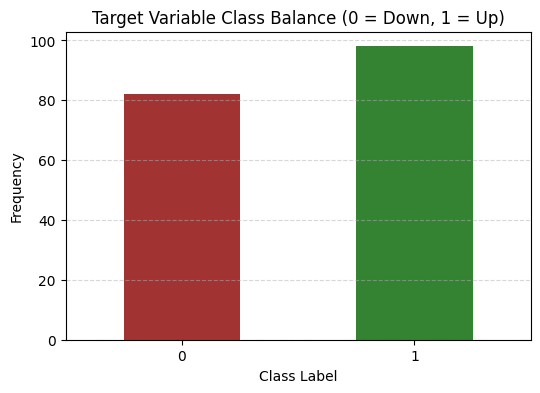

Scaled Features (Values now between 0 and 1) 


,Return_1d_scaled,SMA_5_scaled,SMA_20_scaled,Volatility_10_scaled,Momentum_5_scaled
0,0.598126,0.140094,0.000000,0.230084,0.451739
1,1.000000,0.150872,0.026125,0.497881,0.573318
2,0.247304,0.150903,0.046319,0.696103,0.482634
3,0.706908,0.159589,0.065944,0.677230,0.555666
4,0.293120,0.157497,0.079263,0.772757,0.464713


In [12]:
epsilon = np.random.normal(loc=0.001, scale=0.018, size=days)
prices = P0 * np.cumprod(1 + epsilon)

df = pd.DataFrame({'Price': prices})

df['Return_1d'] = df['Price'].pct_change()
df['SMA_5'] = df['Price'].rolling(window=5).mean()
df['SMA_20'] = df['Price'].rolling(window=20).mean()
df['Volatility_10'] = df['Return_1d'].rolling(window=10).std()
df['Momentum_5'] = df['Price'] - df['Price'].shift(5)

df = df.dropna().reset_index(drop=True)



df['Next_Day_Return'] = df['Return_1d'].shift(-1)

df['Target'] = (df['Next_Day_Return'] > 0).astype(int)

df = df.dropna().reset_index(drop=True)

df = df.drop(columns=['Next_Day_Return'])

class_balance = df['Target'].value_counts()
print("\n--- Target Class Balance ---")
print(f"Up Days (1):   {class_balance[1]}")
print(f"Down Days (0): {class_balance[0]}")

plt.figure(figsize=(6, 4))
class_balance.sort_index().plot(kind='bar', color=['darkred', 'darkgreen'], alpha=0.8)
plt.title('Target Variable Class Balance (0 = Down, 1 = Up)')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']


X = df[feature_cols].values

X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_scaled = (X - X_min) / (X_max - X_min)

df_scaled = pd.DataFrame(X_scaled, columns=[f"{col}_scaled" for col in feature_cols])

print("Scaled Features (Values now between 0 and 1) ")
display(df_scaled.head())

Accuracy for k=3: 50.00%
Accuracy for k=5: 47.22%
Accuracy for k=7: 38.89%
Accuracy for k=11: 38.89%
Accuracy for k=15: 47.22%

Optimal k is 3 with an accuracy of 50.00%


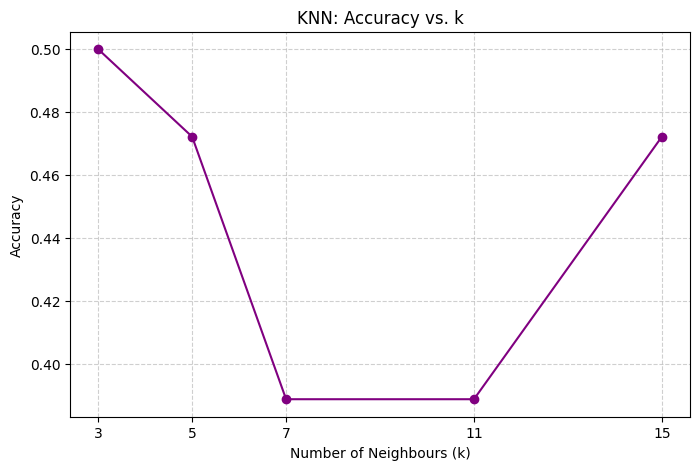

True Positives (TP):  7
True Negatives (TN):  11
False Positives (FP): 4  <-- Bad trades entered
False Negatives (FN): 14  <-- Good trades missed

Precision: 0.6364 (63.64%)
Recall:    0.3333 (33.33%)


In [13]:
y = df['Target'].values
X = X_scaled

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]

        k_indices = np.argsort(distances)[:k]

        k_nearest_labels = [y_train[i] for i in k_indices]

        majority_vote = max(set(k_nearest_labels), key=k_nearest_labels.count)
        predictions.append(majority_vote)

    return np.array(predictions)

split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []


for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)

    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc*100:.2f}%")

# Find the best k
best_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal k is {best_k} with an accuracy of {max(accuracies)*100:.2f}%")

# Plotting Accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='purple')
plt.title('KNN: Accuracy vs. k')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_preds = knn_predict(X_train, y_train, X_test, best_k)

# Compute Confusion Matrix components
TP = np.sum((best_preds == 1) & (y_test == 1))
TN = np.sum((best_preds == 0) & (y_test == 0))
FP = np.sum((best_preds == 1) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))


precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"True Positives (TP):  {TP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}  <-- Bad trades entered")
print(f"False Negatives (FN): {FN}  <-- Good trades missed")

print(f"\nPrecision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")

--- Normal Equation Coefficients ---
Bias           : 0.028269
Return_1d      : -0.015943
SMA_5          : -0.001192
SMA_20         : -0.013571
Volatility_10  : -0.018255
Momentum_5     : -0.009034

Mean Squared Error (MSE): 0.000473
R-squared (R2) Score:     -0.3363


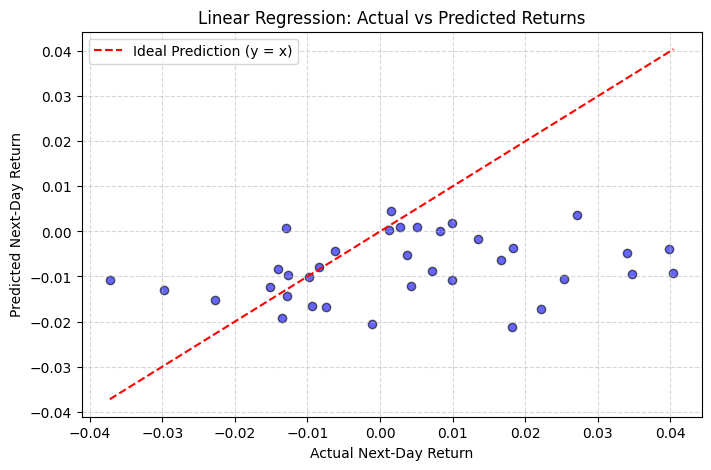


 Gradient Descent Coefficients
Bias           : 0.004363
Return_1d      : -0.001682
SMA_5          : -0.001051
SMA_20         : -0.001141
Volatility_10  : -0.003783
Momentum_5     : -0.000043


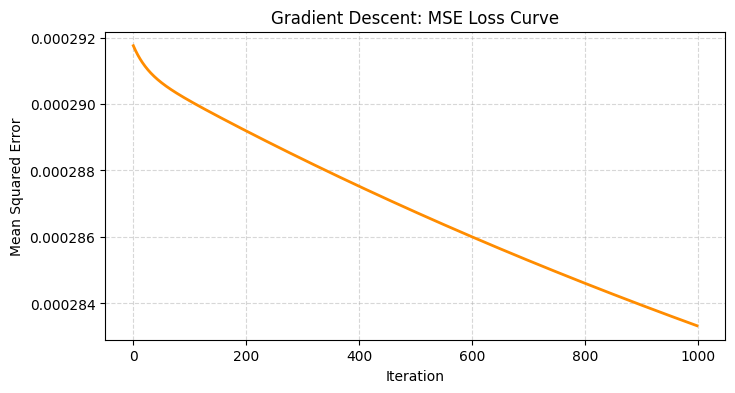

In [14]:

y_cont = df['Return_1d'].shift(-1).dropna().values

X_c = X_scaled[:len(y_cont)]

split_idx = int(len(X_c) * 0.8)
X_train, X_test = X_c[:split_idx], X_c[split_idx:]
y_train, y_test = y_cont[:split_idx], y_cont[split_idx:]

X_train_b = np.c_[np.ones(len(X_train)), X_train]
X_test_b = np.c_[np.ones(len(X_test)), X_test]


beta_normal = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

feature_names = ['Bias', 'Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
print("--- Normal Equation Coefficients ---")
for name, coef in zip(feature_names, beta_normal):
    print(f"{name:15}: {coef:.6f}")


y_pred_normal = X_test_b @ beta_normal

# Mean Squared Error
mse = np.mean((y_test - y_pred_normal)**2)

# R-squared Score
ss_res = np.sum((y_test - y_pred_normal)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_score = 1 - (ss_res / ss_tot)

print(f"\nMean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R2) Score:     {r2_score:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_normal, alpha=0.6, color='blue', edgecolors='k')

limits = [min(y_test.min(), y_pred_normal.min()), max(y_test.max(), y_pred_normal.max())]
plt.plot(limits, limits, 'r--', label='Ideal Prediction (y = x)')
plt.title('Linear Regression: Actual vs Predicted Returns')
plt.xlabel('Actual Next-Day Return')
plt.ylabel('Predicted Next-Day Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

eta = 0.01
iterations = 1000
n = len(y_train)


beta_gd = np.zeros(X_train_b.shape[1])
losses = []

for i in range(iterations):
    y_pred_gd = X_train_b @ beta_gd
    loss = np.mean((y_train - y_pred_gd)**2)
    losses.append(loss)


    gradient = (1/n) * X_train_b.T @ (y_pred_gd - y_train)
    beta_gd -= eta * gradient

print("\n Gradient Descent Coefficients")
for name, coef in zip(feature_names, beta_gd):
    print(f"{name:15}: {coef:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(range(iterations), losses, color='darkorange', linewidth=2)
plt.title('Gradient Descent: MSE Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

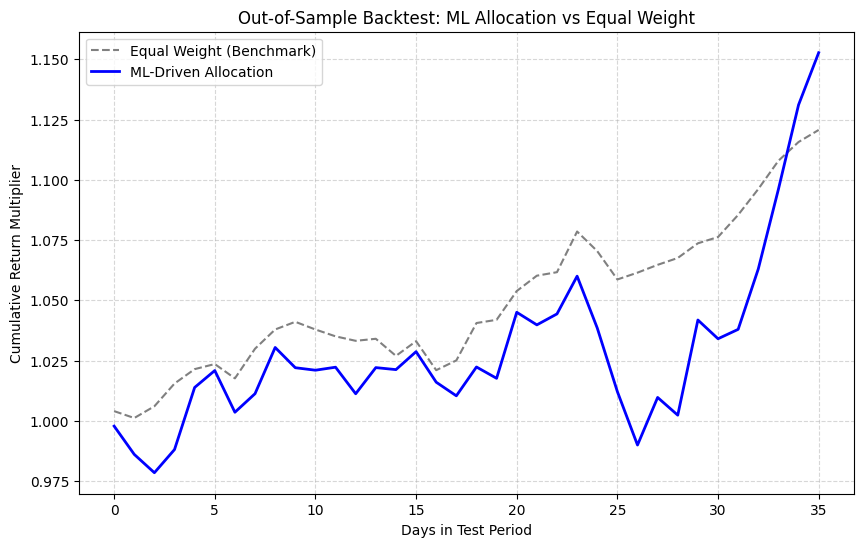

Backtest Results
ML Portfolio Final Return: 15.27%
Equal Weight Final Return: 12.07%


In [15]:
tickers = ['RELIANCE', 'INFY', 'HDFCBANK', 'TATAMOTORS']
start_prices = [2800, 1450, 1600, 520]
days = 300

asset_data = {}

for ticker, p0 in zip(tickers, start_prices):

    eps = np.random.normal(loc=0.001, scale=0.015, size=days)
    prices = p0 * np.cumprod(1 + eps)
    df_asset = pd.DataFrame({'Price': prices})

    df_asset['Return_1d'] = df_asset['Price'].pct_change()
    df_asset['SMA_5'] = df_asset['Price'].rolling(5).mean()
    df_asset['SMA_20'] = df_asset['Price'].rolling(20).mean()
    df_asset['Volatility_10'] = df_asset['Return_1d'].rolling(10).std()
    df_asset['Momentum_5'] = df_asset['Price'] - df_asset['Price'].shift(5)

    df_asset = df_asset.dropna().reset_index(drop=True)
    asset_data[ticker] = df_asset

test_length = len(y_test)

ml_portfolio_returns = []
ew_portfolio_returns = []

for t in range(test_length):
    expected_returns = []
    actual_returns = []

    for ticker in tickers:
        df_asset = asset_data[ticker]

        test_day_idx = split_idx + t
        features = df_asset.loc[test_day_idx, feature_names[1:]].values

        scaled_features = (features - X_min) / (X_max - X_min)

        x_input = np.insert(scaled_features, 0, 1.0)

        mu_hat = np.dot(x_input, beta_normal)
        expected_returns.append(mu_hat)

        actual_returns.append(df_asset.loc[test_day_idx, 'Return_1d'])

    expected_returns = np.array(expected_returns)
    actual_returns = np.array(actual_returns)

    clipped_returns = np.maximum(expected_returns, 0)
    sum_clipped = np.sum(clipped_returns)

    if sum_clipped > 0:
        weights = clipped_returns / sum_clipped
    else:

        weights = np.zeros(4)

    ml_daily_return = np.sum(weights * actual_returns)
    ew_daily_return = np.sum(np.array([0.25, 0.25, 0.25, 0.25]) * actual_returns)

    ml_portfolio_returns.append(ml_daily_return)
    ew_portfolio_returns.append(ew_daily_return)


cum_ml = np.cumprod(1 + np.array(ml_portfolio_returns))
cum_ew = np.cumprod(1 + np.array(ew_portfolio_returns))

plt.figure(figsize=(10, 6))
plt.plot(cum_ew, label='Equal Weight (Benchmark)', color='gray', linestyle='--')
plt.plot(cum_ml, label='ML-Driven Allocation', color='blue', linewidth=2)
plt.title('Out-of-Sample Backtest: ML Allocation vs Equal Weight')
plt.xlabel('Days in Test Period')
plt.ylabel('Cumulative Return Multiplier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Backtest Results")
print(f"ML Portfolio Final Return: {(cum_ml[-1] - 1)*100:.2f}%")
print(f"Equal Weight Final Return: {(cum_ew[-1] - 1)*100:.2f}%")

In [16]:
k_folds = 5
k_knn_options = [3, 7, 11]

n_samples = len(X)
fold_size = n_samples // k_folds

cv_results = {}

print(" 5-Fold Cross Validation Results (KNN) ")

for k_knn in k_knn_options:
    fold_accuracies = []

    for i in range(k_folds):
        start_idx = i * fold_size
        end_idx = start_idx + fold_size if i < (k_folds - 1) else n_samples

        X_test_fold = X[start_idx:end_idx]
        y_test_fold = y[start_idx:end_idx]

        X_train_fold = np.concatenate((X[:start_idx], X[end_idx:]), axis=0)
        y_train_fold = np.concatenate((y[:start_idx], y[end_idx:]), axis=0)

        preds = knn_predict(X_train_fold, y_train_fold, X_test_fold, k_knn)

        fold_acc = np.mean(preds == y_test_fold)
        fold_accuracies.append(fold_acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    cv_results[k_knn] = {'mean': mean_acc, 'std': std_acc}

    print(f"k_KNN = {k_knn:2}: Mean Accuracy = {mean_acc:.4f} | Std Dev = {std_acc:.4f}")

best_k = max(cv_results, key=lambda k: cv_results[k]['mean'])
best_knn_acc = cv_results[best_k]['mean']

summary_data = [
    ['KNN Classifier', f"{best_knn_acc:.4f}", 'N.A.', f"k = {best_k}"],
    ['Linear Regression', f"{r2_score:.4f}", f"{mse:.6f}", 'Normal Equation']
]

summary_df = pd.DataFrame(summary_data, columns=['Model', 'Accuracy/R²', 'MSE/N.A.', 'Best Param'])

print("Model Performance Summary")
display(summary_df)

 5-Fold Cross Validation Results (KNN) 
k_KNN =  3: Mean Accuracy = 0.5389 | Std Dev = 0.0671
k_KNN =  7: Mean Accuracy = 0.4722 | Std Dev = 0.0766
k_KNN = 11: Mean Accuracy = 0.4778 | Std Dev = 0.0539
Model Performance Summary


,Model,Accuracy/R²,MSE/N.A.,Best Param
0,KNN Classifier,0.5389,N.A.,k = 3
1,Linear Regression,-0.3363,0.000473,Normal Equation


a) DiversificationTo put it simply, portfolio variance ($\sigma_p^2$) comes from two things: the individual risk of each asset, and how they move together (covariance). The correlation coefficient ($\rho_{ij}$) scales that covariance term. If everything moves in lockstep ($\rho_{ij} = 1$), your risk maxes out. But if you mix in assets that don't care about each other, or move in opposite directions ($\rho_{ij} \le 0$), that covariance term drops to zero or goes negative. This actively pulls your total portfolio risk down without necessarily killing your expected returns—hence the "free lunch."

b) Technical vs. Fundamental Analysis in MLA good fundamental feature to add is Earnings Yield (the inverse of P/E). It forces the model to look at actual business profitability, not just chart momentum. You could grab quarterly earnings from an API like Yahoo Finance or Alpha Vantage. Since earnings only come out four times a year, you just forward-fill that value for every daily row until the next release hits. Just make sure to apply Min-Max scaling to it so the raw numbers don't totally warp the Euclidean distance math in the KNN algorithm.

c) The Curse of DimensionalityAs you keep throwing more features into a model, the data space blows up exponentially, spreading the points way too far apart. In high dimensions, the math breaks down—the distance between your "closest" point and your "farthest" point ends up looking roughly the same. If every historical day is basically the same distance from today, KNN completely loses its edge because "nearest neighbour" doesn't mean anything anymore. A standard fix is running PCA first to compress everything down to a few core features that still capture most of the variance.

d) Overfitting in BacktestingIf you see a Sharpe ratio of 3.5 in a backtest but 0.4 in live trading, you've probably just curve-fit the noise. Three big reasons for this gap are: 1) Look-ahead bias (like accidentally using the closing price to generate a morning signal), 2) Survivorship bias (only testing on stocks that survived, completely ignoring bankruptcies), and 3) Data snooping (tweaking moving average windows until they magically fit the historical data perfectly). The best way to catch this before going live is using Walk-Forward Analysis (time-series cross-validation) to test the model strictly out-of-sample, block by block.

e) Linear Regression AssumptionsFinancial time-series data pretty much shreds the standard i.i.d. assumptions of linear regression. First, you get volatility clustering (heteroskedasticity)—big market swings usually group together, which breaks the rule of constant variance and ruins your standard errors. Second is autocorrelation. Today's price action is obviously influenced by yesterday's momentum, which violates the independence rule. This usually makes the model way too confident in its own weights, leading to garbage predictions when testing out-of-sample.